# 06 — SRD Loss Pre-Training

**Purpose:** Train the GRU4Rec sequential recommendation backbone using
**Soft-Rank Diversity (SRD) Loss** — Method 1 of the two-stage BDC recommender
training pipeline.

## Theory: SRD Loss

SRD combines standard cross-entropy (accuracy objective) with a differentiable
intra-list diversity penalty:

$$\mathcal{L}_{\text{SRD}} = \mathcal{L}_{\text{CE}} + w_{\text{div}} \cdot \mathcal{L}_{\text{div}}$$

where:

$$\mathcal{L}_{\text{div}} = \sum_{b} \mathbf{w}_b^\top S \mathbf{w}_b$$

- $\mathbf{w}_b = \text{softmax}(\text{logits}_b / \tau)$ — soft selection weights
- $S_{ij} = \cos(\mathbf{e}_i, \mathbf{e}_j)$ — item embedding cosine similarity
- $\tau$ — temperature hyperparameter
- $w_{\text{div}}$ — diversity loss weight (default: 0.1)

## Model

**GRU4Rec backbone**: Embedding → GRU → Linear → logits over item vocabulary.

## Usage

This notebook shows a reduced 3-epoch demo. For full training:
```bash
python scripts/train_srd.py --epochs 20
```

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

GOLD_DIR   = os.environ.get('BDC_GOLD_DIR', '../data/lakehouse/gold')
DUCKDB_PATH = os.environ.get('BDC_DUCKDB_PATH', '../data/student_analytics.duckdb')
OUTPUT_DIR = '../output/slates'
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.13.0+cu130


## 1. Import SRD Components from `scripts/train_srd.py`

We reuse the production-grade implementations directly. No duplication.

In [2]:
from scripts.train_srd import (
    InteractionSequenceDataset,
    GRU4RecBackbone,
    SRDLoss,
    train as srd_train_epoch,
)

print('SRD components imported successfully.')
print(f'  InteractionSequenceDataset: {InteractionSequenceDataset}')
print(f'  GRU4RecBackbone:            {GRU4RecBackbone}')
print(f'  SRDLoss:                    {SRDLoss}')

SRD components imported successfully.
  InteractionSequenceDataset: <class 'scripts.train_srd.InteractionSequenceDataset'>
  GRU4RecBackbone:            <class 'scripts.train_srd.GRU4RecBackbone'>
  SRDLoss:                    <class 'scripts.train_srd.SRDLoss'>


## 2. Load Training Data

In [3]:
from scripts.load_data import load_gold_table, train_test_split_temporal

df = None

# Try DuckDB first
if os.path.exists(DUCKDB_PATH):
    try:
        from scripts.load_data import load_duckdb_view
        df = load_duckdb_view(
            'SELECT user_id, node_id, created_at FROM unified_interactions ORDER BY created_at ASC'
        )
        print(f'[DuckDB] Loaded {len(df):,} interactions.')
    except Exception as e:
        print(f'[DuckDB] Failed: {e}')

# Try Parquet fallback
if df is None:
    parquet_path = os.path.join(GOLD_DIR, 'gold_user_item_matrix.parquet')
    if os.path.exists(parquet_path):
        df_raw = pd.read_parquet(parquet_path)
        df = df_raw[['user_id', 'node_id']].copy()
        df['created_at'] = pd.date_range('2024-01-01', periods=len(df), freq='5min')
        print(f'[Parquet] Loaded {len(df):,} interactions from gold_user_item_matrix.')

# Synthetic demo
if df is None:
    print('[Demo] Generating synthetic sequence data...')
    rng = np.random.default_rng(42)
    n = 5000
    df = pd.DataFrame({
        'user_id':    rng.integers(1, 51, n),
        'node_id':    rng.integers(100, 160, n),
        'created_at': pd.date_range('2024-01-01', periods=n, freq='20min'),
    })

print(f'Training data shape: {df.shape}')
print(f'Unique users: {df["user_id"].nunique():,}')
print(f'Unique items: {df["node_id"].nunique():,}')
display(df.head(5))

[Parquet] Loaded 1,158 interactions from gold_user_item_matrix.
Training data shape: (1158, 3)
Unique users: 100
Unique items: 20


,user_id,node_id,created_at
0,1,1009,2024-01-01 00:00:00
1,1,1017,2024-01-01 00:05:00
2,1,1001,2024-01-01 00:10:00
3,1,1020,2024-01-01 00:15:00
4,1,1012,2024-01-01 00:20:00


## 3. Build Dataset & DataLoader

In [4]:
SEQ_LEN    = 10
BATCH_SIZE = 64

train_df, _ = train_test_split_temporal(df, test_frac=0.1)

dataset    = InteractionSequenceDataset(train_df, seq_len=SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

VOCAB_SIZE = dataset.vocab_size

print(f'Vocabulary size:     {VOCAB_SIZE:,}')
print(f'Training samples:    {len(dataset):,}')
print(f'Batches per epoch:   {len(dataloader):,}')

# Show sample batch
sample_seqs, sample_targets = next(iter(dataloader))
print(f'\nSample batch shapes:')
print(f'  sequences: {tuple(sample_seqs.shape)}   (batch, seq_len)')
print(f'  targets:   {tuple(sample_targets.shape)}  (batch,)')

Vocabulary size:     20
Training samples:    987
Batches per epoch:   15

Sample batch shapes:
  sequences: (64, 10)   (batch, seq_len)
  targets:   (64,)  (batch,)


## 4. Train GRU4RecBackbone with SRD Loss (3-epoch demo)

In [5]:
N_EPOCHS   = 3      # Reduced for demo; use 20 for full training
W_DIV      = 0.1
TEMPERATURE = 1.0
LR          = 1e-3

model     = GRU4RecBackbone(vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = SRDLoss(temperature=TEMPERATURE, w_div=W_DIV)

print(f'Model architecture:')
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')
print(f'\nSRD hyperparameters: temperature={TEMPERATURE}, w_div={W_DIV}')
print()

epoch_losses = []
for epoch in range(1, N_EPOCHS + 1):
    avg_loss = srd_train_epoch(model, dataloader, optimizer, criterion, device, epoch)
    epoch_losses.append(avg_loss)

print(f'\nFinal loss: {epoch_losses[-1]:.4f}')

Model architecture:
GRU4RecBackbone(
  (embedding): Embedding(21, 64, padding_idx=0)
  (gru): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=20, bias=True)
)

Trainable parameters: 78,420

SRD hyperparameters: temperature=1.0, w_div=0.1

[SRD] Epoch   1 | Loss: 3.0043
[SRD] Epoch   2 | Loss: 2.9384
[SRD] Epoch   3 | Loss: 2.8940

Final loss: 2.8940


## 5. Training Loss Curve

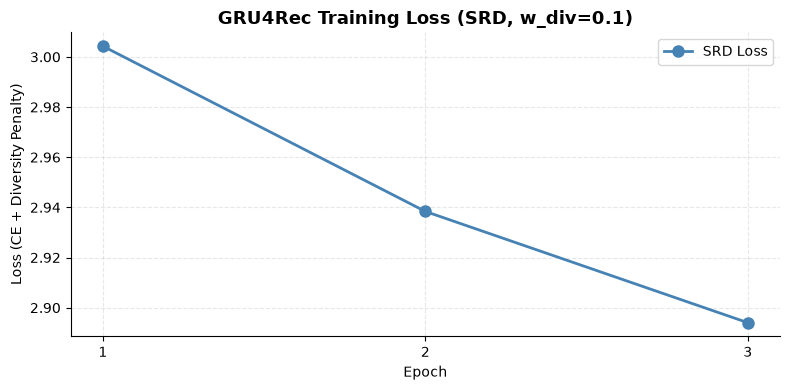

Loss curve saved to ../output/srd_training_loss.png


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_EPOCHS + 1), epoch_losses, 'o-', color='steelblue',
        linewidth=2, markersize=8, label='SRD Loss')
ax.set_title(f'GRU4Rec Training Loss (SRD, w_div={W_DIV})', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (CE + Diversity Penalty)')
ax.set_xticks(range(1, N_EPOCHS + 1))
ax.grid(alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../output/srd_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curve saved to ../output/srd_training_loss.png')

## 6. Save Checkpoint

In [7]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'srd_model.pt')

torch.save({
    'state_dict': model.state_dict(),
    'item_vocab': dataset.item_vocab,
    'vocab_size': VOCAB_SIZE,
    'epoch_losses': epoch_losses,
    'hyperparams': {
        'temperature': TEMPERATURE,
        'w_div': W_DIV,
        'seq_len': SEQ_LEN,
        'embed_dim': 64,
        'hidden_dim': 128,
        'epochs_trained': N_EPOCHS,
    },
}, checkpoint_path)

print(f'Checkpoint saved to: {checkpoint_path}')

# Verify: reload and check
ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
print(f'Verified checkpoint keys: {list(ckpt.keys())}')
print(f'Vocab size in checkpoint: {ckpt["vocab_size"]}')
print(f'Epochs trained:           {ckpt["hyperparams"]["epochs_trained"]}')
print()
print('=' * 50)
print('For full training run:')
print('  python scripts/train_srd.py --epochs 20 --output output/slates/srd_model.pt')
print('=' * 50)

Checkpoint saved to: ../output/slates/srd_model.pt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 